# Week 12: Gaussian Processes

### Aims:
* To complement lecture material in understanding Gaussian processes (GPs) for regression.
* To gain experience with simulating and implementing Gaussian process regression in
software.
* To produce some assessable work for this subject.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from numpy.random import multivariate_normal

In [2]:
# ANSI color
class color:
  GREEN_BOLD = '\033[1;32m'
  YELLOW_BOLD = '\033[1;33m'
  BLUE_BOLD = '\033[1;34m'
  WHITE_BOLD = '\033[1;37m'
  END = '\033[0m'

### Gaussian process regression:
Note: This Prac does not refer directly to the textbook, so the notation will be slightly
different to that seen in lectures. However, dealing with different notation between resources
is a fact of life in Machine Learning so it is good experience for the course.
* Read §2.2 of Gaussian Processes for Machine Learning, freely available [here](https://gaussianprocess.org/gpml/chapters/RW.pdf).

### Question 1: The squared exponential covariance function is given by

$$ k(\mathbf{x}_p, \mathbf{x}_q) = \exp\left(-\frac{1}{2\ell^2} \|\mathbf{x}_p - \mathbf{x}_q\|_2^2 \right),
$$

where $\|\|\cdot\|\|_2$ denotes the Euclidean norm and $\ell$ is a hyperparameter called length-scale.

Write a function $\texttt{K}$, which accepts three inputs. The first and second inputs should be an $n \times d$ array $X$ and an $m \times d$ array $X_*$ respectively. The third input should be the float $\ell$. The function should return an $n \times m$ array with $pq^{th}$ element equal to $k$ evaluated at the *p*th row of $X$ and the *q*th row of $X_*$.

In [65]:
# def K(X, X_star, ell):
#     """
#     Compute the squared exponential kernel matrix between X and X_star.

#     Parameters:
#     - X: numpy array of shape (n, d)
#     - X_star: numpy array of shape (m, d)
#     - ell: float, length-scale parameter

#     Returns:
#     - K_matrix: numpy array of shape (n, m) with kernel values
#     """
#     # Compute squared distances using broadcasting
#     X_norm_sq = np.sum(X**2, axis=1).reshape(-1, 1)            # shape (n, 1)
#     X_star_norm_sq = np.sum(X_star**2, axis=1).reshape(1, -1)  # shape (1, m)
#     cross_term = X @ X_star.T                                  # shape (n, m)

#     dists_sq = X_norm_sq - 2 * cross_term + X_star_norm_sq     # shape (n, m)
#     K_matrix = np.exp(-0.5 / ell**2 * dists_sq)

#     return K_matrix


def K(X, X_star, ell):
    dists_sq = cdist(X, X_star, 'sqeuclidean')
    K_matrix = np.exp(-0.5 / ell**2 * dists_sq)
    return K_matrix

X = np.loadtxt('train_inputs').reshape(-1, 1)
X_star = np.loadtxt('test_inputs').reshape(-1, 1)
ell = 1.0

print(K(X, X_star, ell))

[[3.64077907e-17 5.30310303e-17 7.70993417e-17 ... 1.40146708e-04
  1.16653320e-04 9.69161108e-05]
 [6.62454649e-05 8.00397982e-05 9.65251527e-05 ... 1.63352720e-16
  1.12785814e-16 7.77262023e-17]
 [2.64862822e-10 3.52853163e-10 4.69193304e-10 ... 2.86489425e-09
  2.18102167e-09 1.65728092e-09]
 ...
 [2.81733817e-04 3.35371125e-04 3.98471278e-04 ... 8.23741520e-18
  5.60345522e-18 3.80457134e-18]
 [3.03741347e-04 3.61276508e-04 4.28904098e-04 ... 6.98061111e-18
  4.74468639e-18 3.21889239e-18]
 [3.50429664e-18 5.16325640e-18 7.59331472e-18 ... 4.13184408e-04
  3.47892630e-04 2.92368915e-04]]


### Question 2: Write a function sample prior which accepts three inputs. The first input should be an $n \times d$ array $X$. The second input should be the float $\ell$. The third input $N$ should be an integer representing the number of desired samples. The function should return an $N \times n$ array representing $N$ samples from the GP prior with mean **0** and squared exponential covariance function with length-scale $\ell$.

In [66]:
def sample_prior(X, ell, N):
    """
    Sample N functions from a GP prior with zero mean and
    squared exponential kernel (usaes K function).

    Parameters:
    - X: (n, d) array of input points
    - ell: length-scale parameter (float)
    - N: number of samples to draw (int)

    Returns:
    - (N, n) array: Each row is a GP sample over X
    """
    n = X.shape[0]

    # Use the K function to compute the kernel matrix
    K_matrix = K(X, X, ell)

    # Add small jitter for numerical stability
    K_matrix += 1e-6 * np.eye(n)

    # Sample N functions (N rows of n-length vectors)
    samples = np.random.multivariate_normal(mean=np.zeros(n), cov=K_matrix, size=N)

    return samples

### Question 3: Test the functionality of sample prior by plotting 5 samples from the prior. Use the test inputs data for $X$, $\ell = 1$ and $N = 5$. The samples should look different each time the plot is generated - why?

> Hint: Your plot should look something like the plot below, but should have appropriate axis
labels.



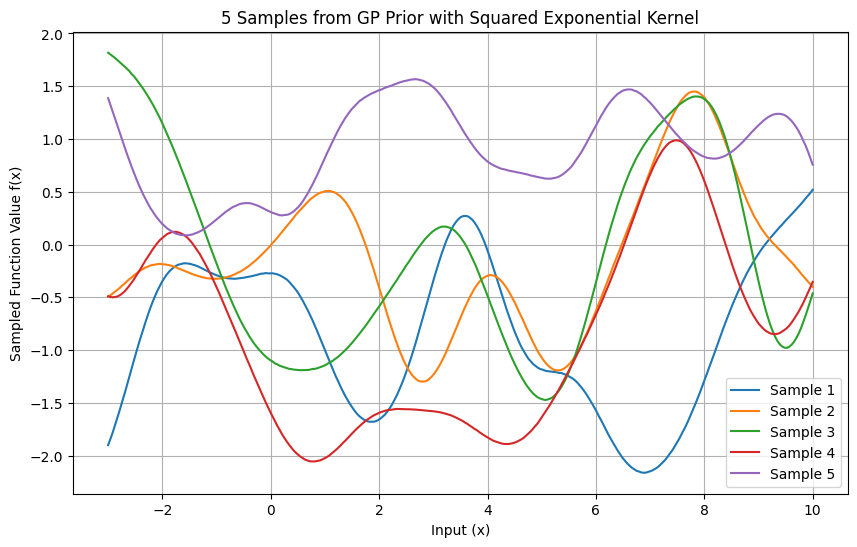

In [68]:
#        Test Inputs
X = np.loadtxt('test_inputs').reshape(-1, 1)
X = X[np.argsort(X[:, 0])]
ell = 1.0
N = 5

#        Generate Samples
samples = sample_prior(X, ell, N)

#        Plotting
plt.figure(figsize=(10, 6))
for i in range(N):
    plt.plot(X.ravel(), samples[i], label=f"Sample {i+1}")

plt.title(f"{N} Samples from GP Prior with Squared Exponential Kernel")
plt.xlabel("Input (x)")
plt.ylabel("Sampled Function Value f(x)")
plt.grid(True)
plt.legend()
plt.show()

### Question 4: Write a function predictive mean implementing equation 2.23 of [1]. The function should take 5 inputs: The $n \times d$ array of training input data $X$, the $n \times 1$ array of training target data **y**, the $m \times d$ array of prediction input data $X_*$, the float $\ell$ and the float representing the noise parameter $\sigma_n$. The function should return an $m \times 1$ array representing the mean of the posterior predictive distribution at $X_*$.

In [69]:
# def predictive_mean(X, y, X_star, ell, sigma_n):
#     """
#     Compute the posterior predictive mean at test points X_star.

#     Parameters:
#     - X: (n, d) training inputs
#     - y: (n, 1) training targets
#     - X_star: (m, d) test inputs
#     - ell: length-scale parameter
#     - sigma_n: noise standard deviation

#     Returns:
#     - (m, 1) posterior predictive mean at X_star
#     """
#     # Covariance matrices
#     K_xx = K(X, X, ell) + sigma_n**2 * np.eye(X.shape[0])
#     K_xxs = K(X, X_star, ell)  # shape (n, m)

#     # Solve for alpha = (K_xx + σ_n² I)⁻¹ y using a stable method
#     alpha = np.linalg.solve(K_xx, y)  # shape (n, 1)

#     # Predictive mean: μ* = K(X*, X) @ α
#     mu_star = K_xxs.T @ alpha  # shape (m, 1)

#     return mu_star


def predictive_mean(X, y, X_star, ell, sigma_n):
    K_xx = K(X, X, ell) + sigma_n**2 * np.eye(X.shape[0])
    K_xxs = K(X, X_star, ell)
    alpha = np.linalg.solve(K_xx, y)
    return K_xxs.T @ alpha

### Question 5: Write a function $\texttt{predictive_cov}$ implementing equation 2.24 of [1]. The function should take 5 inputs: The $n \times d$ array of training input data $X$, the $n \times 1$ array of training target data **y**, the $m \times d$ array of prediction input data $X_*$, the float $\ell$ and the float representing the noise parameter $\sigma_n$. The function should return an $m \times m$ array representing the covariance of the posterior predictive distribution at $X_*$.

> Hint: The plot below shows the predictive posterior mean and predictive posterior standard deviation (square root of diagonal entries of the covariance matrix) on top of the training data, when *X* is $\texttt{train_inputs}$, *y* is $\texttt{train_outputs}$, $X_*$ is $\texttt{test_inputs}$, $\ell = 1$ and $\sigma_n = 1$.

In [70]:
# def predictive_cov(X, y, X_star, ell, sigma_n):
#     """
#     Compute the posterior predictive covariance matrix at test points X_star.

#     Parameters:
#     - X: (n, d) training inputs
#     - y: (n, 1) training outputs (unused here but kept for API consistency)
#     - X_star: (m, d) test inputs
#     - ell: length-scale parameter
#     - sigma_n: noise standard deviation

#     Returns:
#     - (m, m) predictive covariance matrix
#     """
#     # Covariance matrices
#     K_xx = K(X, X, ell) + sigma_n**2 * np.eye(X.shape[0])  # shape (n, n)
#     K_xxs = K(X, X_star, ell)                              # shape (n, m)
#     K_ss = K(X_star, X_star, ell)                          # shape (m, m)

#     # Solve for inverse using linear system
#     v = np.linalg.solve(K_xx, K_xxs)                       # shape (n, m)

#     # Predictive covariance: cov(f*) = K(X_*, X_*) - K(X_*, X) @ inv(K_xx) @ K(X, X_*)
#     cov_star = K_ss - K_xxs.T @ v                          # shape (m, m)

#     return cov_star

def predictive_cov(X, y, X_star, ell, sigma_n):
    K_xx = K(X, X, ell) + sigma_n**2 * np.eye(X.shape[0])
    K_xxs = K(X, X_star, ell)
    K_ss = K(X_star, X_star, ell)
    v = np.linalg.solve(K_xx, K_xxs)
    return K_ss - K_xxs.T @ v

### Question 6: Test the functionality of $\texttt{predictive_mean}$ and $\texttt{predictive_cov}$ by plotting 5 samples from the predictive posterior with the training data. Use the $\texttt{train_inputs}$ data for $X$, $\texttt{train_outputs}$ data for **y**, $\texttt{train_inputs}$ data for $X_*$, $\ell = 1$, $\sigma_n = 1$ and generate $N = 5$ samples. The samples should look different each time the plot is generated - why?

> Hint: Your plot should look something like the plot below, but with labelled axes.

In [73]:
# def plot_gp_posterior_samples(X, y, ell, sigma_n, N):
#     """
#     Plot N samples from the GP posterior at training points X.

#     Parameters:
#     - X: (n, d) training inputs and test inputs
#     - y: (n, 1) training outputs
#     - ell: float, length-scale
#     - sigma_n: float, noise level
#     - N: number of samples
#     """
#     # Step 1: Compute predictive mean and covariance at X
#     mu_star = predictive_mean(X, y, X, ell, sigma_n)  # shape (n, 1)
#     cov_star = predictive_cov(X, y, X, ell, sigma_n)  # shape (n, n)

#     # Step 2: Sample N functions from the posterior
#     samples = np.random.multivariate_normal(
#         mean=mu_star.ravel(), cov=cov_star, size=N
#     )

#     # Step 3: Plotting
#     plt.figure(figsize=(10, 6))
#     plt.plot(X, y, 'ko', label='Training data')

#     for i in range(N):
#         plt.plot(X.ravel(), samples[i], label=f'Sample {i+1}')

#     plt.title("Samples from GP Posterior at Training Points")
#     plt.xlabel("x")
#     plt.ylabel("f(x)")
#     plt.grid(True)
#     plt.legend()
#     plt.show()

def plot_gp_posterior_samples(X, y, ell, sigma_n, N):
    mu = predictive_mean(X, y, X, ell, sigma_n).ravel()
    cov = predictive_cov(X, y, X, ell, sigma_n)
    samples = multivariate_normal(mean=mu, cov=cov, size=N)

    std = np.sqrt(np.diag(cov))

    # Plot
    plt.figure(figsize=(10, 6))
    # for i in range(N):
    #     plt.plot(X.ravel(), samples[i], label=f'Sample {i+1}')
    plt.plot(X, y, 'k*', label='Training data')
    plt.plot(X.ravel(), mu, 'r-', lw=2, label='Predictive mean')
    plt.fill_between(X.ravel(), mu - 2*std, mu + 2*std, color='blue', alpha=0.2, label='±2 std dev')

    plt.title("GP Posterior Samples at Training Points")
    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.grid(True)
    plt.legend()
    plt.show()

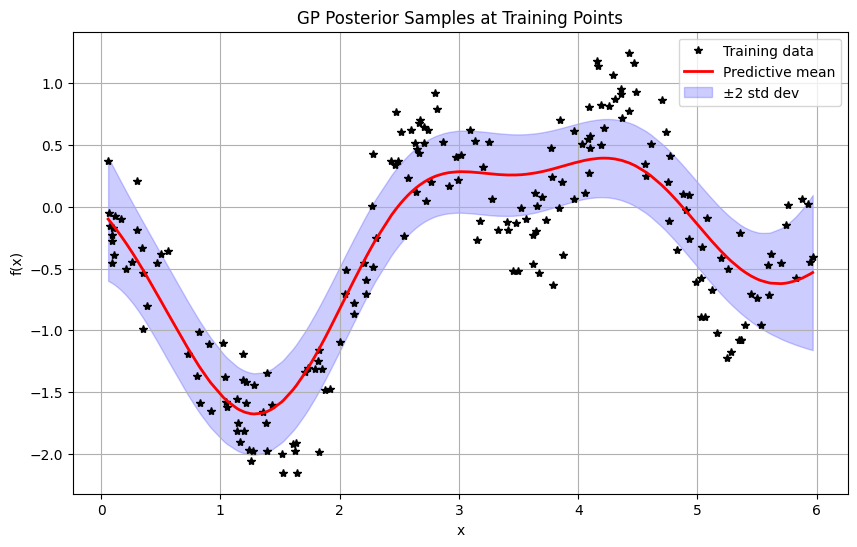

In [74]:
train_inputs = np.loadtxt('train_inputs').reshape(-1, 1)
train_outputs = np.loadtxt('train_outputs').reshape(-1, 1)

# Concatenate and sort by input values
sorted_data = np.hstack((train_inputs, train_outputs))
sorted_data = sorted_data[np.argsort(sorted_data[:, 0])]

# Split back into inputs and outputs
train_inputs = sorted_data[:, 0].reshape(-1, 1)
train_outputs = sorted_data[:, 1].reshape(-1, 1)

plot_gp_posterior_samples(train_inputs, train_outputs, ell=1.0, sigma_n=1.0, N=1)

### Datasets:
All of the data in this practical is taken from the SPGP .zip folder on this website http://www.gatsby.ucl.ac.uk/~snelson/

### Useful Python Commands:
`scipy.spatial.distance.cdist`, `numpy.random.multivariate_normal`,
`matplotlib.pyplot.fill_between`

### Useful Matlab Commands:
`pdist2`, `mvnrnd`, `fill`

### Additional Resources:
1. Gaussian Processes for Machine Learning, freely available here.
2. You can swap out the kernel from **Q1** for different kernels. A gentle introduction to other
kernels is here.